In [85]:
from influxdb import InfluxDBClient
import random
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime

host = '149.62.71.186'
user = 'admin'
password = 'fis_influx'
port=8086
client = InfluxDBClient(host, port, user, password)

In [86]:
client.switch_database('Naloga 0')

# (a)

In [70]:
def narisi_zadnjo_minuto(database, measurement, field):
    
    #query
    result=client.query(f'SELECT "{field}" FROM "{database}".."{measurement}" WHERE "time" > now() - 1m')
    
    
    #directly from raw data
    #values = [result.raw['series'][0]['values'][i][1] for i in range(len(result.raw['series'][0]['values']))]
    
    #done nicely
    points = result.get_points()
    values, times = [],[]
    for point in points:
        times.append(point['time'])
        values.append(point['T1'])
        
    #turn to seconds     
    dt = [datetime.fromisoformat(i.replace('Z', '+00:00')).timestamp() for i in times]
    #start from zero time
    dt_zero = [i-dt[0] for i in dt]
    
    plt.figure(figsize = (12,4))
    plt.plot(dt_zero,values)

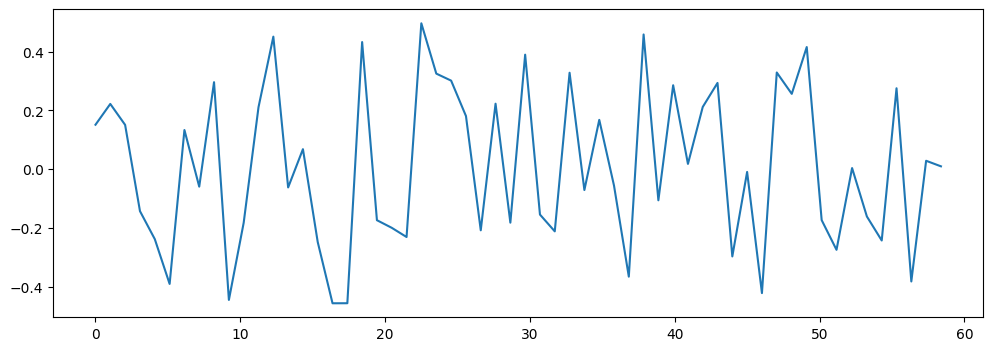

In [71]:
narisi_zadnjo_minuto('Naloga 0', 'Temperature', 'T1')

# (b)

In [72]:
def narisi_predzadnjo_minuto(database, measurement, field):
    #query
    result=client.query(f'SELECT "{field}" FROM "{database}".."{measurement}" WHERE "time" > now() - 2m AND "time" < now() - 1m')
    
    #directly from raw data
    #values = [result.raw['series'][0]['values'][i][1] for i in range(len(result.raw['series'][0]['values']))]
    
    #done nicely
    points = result.get_points()
    values, times = [],[]
    for point in points:
        times.append(point['time'])
        values.append(point['T1'])
        
    #turn to seconds     
    dt = [datetime.fromisoformat(i.replace('Z', '+00:00')).timestamp() for i in times]
    #start from zero time
    dt_zero = [i-dt[0] for i in dt]
    
    plt.figure(figsize = (12,4))
    plt.plot(dt_zero,values)

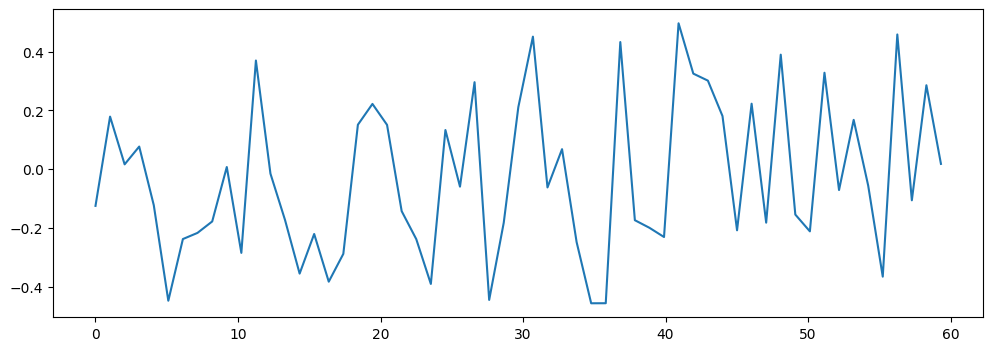

In [73]:
narisi_predzadnjo_minuto('Naloga 0', 'Temperature', 'T1')

# (c)

In [74]:
def narisi_vecje_od_nic(database, measurement, field):
    #query
    result=client.query(f'SELECT "{field}" FROM "{database}".."{measurement}" WHERE "{field}" > 0')
    
    #directly from raw data
    #values = [result.raw['series'][0]['values'][i][1] for i in range(len(result.raw['series'][0]['values']))]

    
    #done nicely
    points = result.get_points()
    values, times = [],[]
    for point in points:
        times.append(point['time'])
        values.append(point['T1'])
        
    #turn to seconds     
    dt = [datetime.fromisoformat(i.replace('Z', '+00:00')).timestamp() for i in times]
    #start from zero time
    dt_zero = [i-dt[0] for i in dt]
    
    plt.figure(figsize = (12,4))
    plt.plot(dt_zero,values)

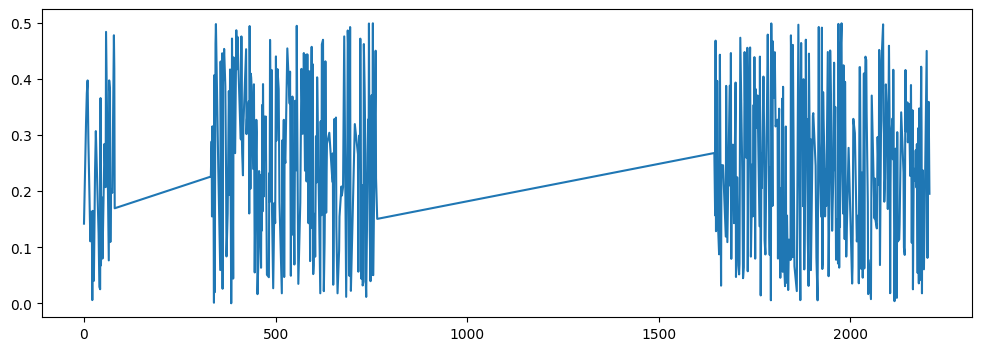

In [75]:
narisi_vecje_od_nic('Naloga 0', 'Temperature', 'T1')

In [48]:
result.raw['series'][0]['values'][0]

['2026-04-14T06:46:28.620270Z', 0.14207638500309916]

In [95]:
result=client.query(f'SELECT "T1" FROM "Naloga 0".."Temperature" WHERE "time" > now() - 1m')


#directly from raw data
#values = [result.raw['series'][0]['values'][i][1] for i in range(len(result.raw['series'][0]['values']))]

In [100]:
#done nicely
points = result.get_points()
values, times = [],[]
for point in points:
    cas, vrednost =point['time'], point['T1']
    print(cas, vrednost)
    break

2026-04-14T16:32:08.507822Z -0.4641313780954691


In [94]:
#turn to seconds     
dt = [datetime.fromisoformat(i.replace('Z', '+00:00')).timestamp() for i in times]
#start from zero time
dt_zero = [i-dt[0] for i in dt]

plt.figure(figsize = (12,4))
plt.plot(times,value

'04/14/2026'